In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df=pd.read_csv('train.csv')  #The dataset is loaded from a CSV file, and the first few rows are displayed for initial exploration.
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [28]:
# Handling Missing Values in 'Postal Code' ---
# Check the number of missing values before processing
missing_count = df['Postal Code'].isnull().sum()
print(f"Missing Postal Codes: {missing_count}")

Missing Postal Codes: 11


In [29]:
# Filtering rows where 'Postal Code' is null and selecting specific columns
missing_data = df[df['Postal Code'].isnull()][['City', 'State']]
print("Cities and States with missing postal codes:")
print(missing_data.drop_duplicates())

Cities and States with missing postal codes:
            City    State
2234  Burlington  Vermont


In [ ]:
# Filling the missing postal code for Burlington, Vermont with 05401
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont'), 'Postal Code'] = 5401.0

# Confirming that no missing values remain in the entire dataset
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


In [31]:
# Date columns are converted to datetime format with errors='coerce' to handle any inconsistent data
# dayfirst=True is used to ensure European-style dates are parsed correctly
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Any rows that failed to convert (NaT) are checked to ensure data integrity
print(f"Missing values in Order Date: {df['Order Date'].isnull().sum()}")

# Now time components are safely extracted
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

Missing values in Order Date: 0


In [ ]:
# 1. Total Sales: Calculate the sum of all sales in the dataset
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

# 2. YoY (Year-over-Year) Growth: Compare current year's sales with the previous year

# Group total sales by year
yearly_summary = df.groupby('Order Year')['Sales'].sum().reset_index()

# Calculate the percentage change between years
yearly_summary['YoY Growth (%)'] = yearly_summary['Sales'].pct_change() * 100

# Rename columns for professional look in the report
yearly_summary.columns = ['Order Year', 'Total Sales', 'YoY Growth (%)']

print(yearly_summary)

Total Sales: $2,261,536.78
   Order Year  Total Sales  YoY Growth (%)
0        2015  479856.2081             NaN
1        2016  459436.0054       -4.255484
2        2017  600192.5500       30.636812
3        2018  722052.0192       20.303396


In [ ]:
# Round the sales and growth figures for a cleaner look
yearly_summary['Total Sales'] = yearly_summary['Total Sales'].round(2)
yearly_summary['YoY Growth (%)'] = yearly_summary['YoY Growth (%)'].fillna(0).round(2)

# Display the polished summary table
print("Business Health Metrics Summary:")
print(yearly_summary)

Business Health Metrics Summary:
   Order Year  Total Sales  YoY Growth (%)
0        2015    479856.21            0.00
1        2016    459436.01           -4.26
2        2017    600192.55           30.64
3        2018    722052.02           20.30


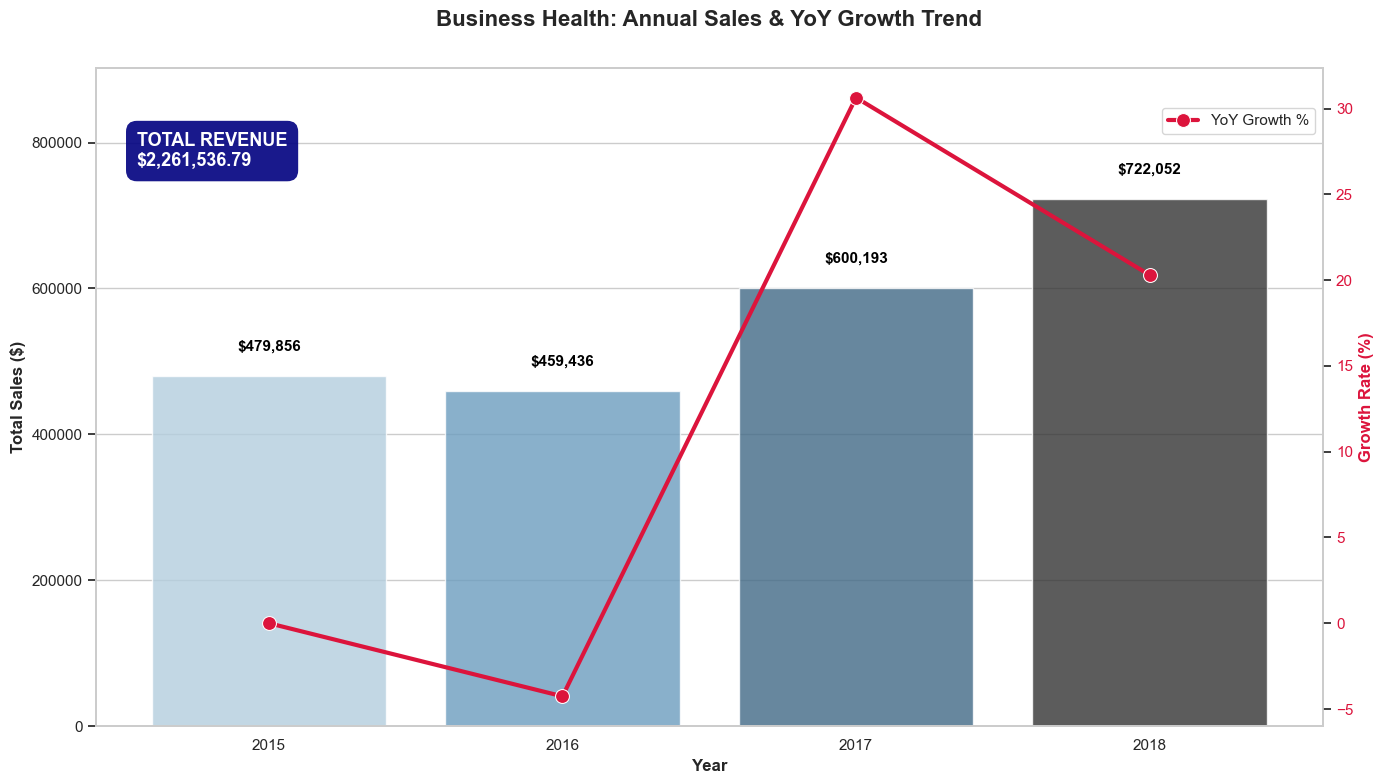

In [ ]:


# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure and axes
fig, ax1 = plt.subplots(figsize=(14, 8)) 

# 1. Bar Chart: Total Sales
sns.barplot(
    x='Order Year', 
    y='Total Sales', 
    data=yearly_summary, 
    ax=ax1, 
    hue='Order Year', 
    palette='Blues_d', 
    alpha=0.8,
    legend=False
)

# Set labels for the primary Y-axis
ax1.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_title('Business Health: Annual Sales & YoY Growth Trend', fontsize=16, pad=30, fontweight='bold')

# Increase Y-axis limit to give space for the KPI card and labels
ax1.set_ylim(0, yearly_summary['Total Sales'].max() * 1.25)

# 2. Secondary Y-axis: YoY Growth Line
ax2 = ax1.twinx()
sns.lineplot(
    x=range(len(yearly_summary)), 
    y='YoY Growth (%)', 
    data=yearly_summary, 
    marker='o', 
    markersize=10, # Nöqtələri böyütdük
    color='crimson', 
    linewidth=3, 
    ax=ax2, 
    label='YoY Growth %'
)

# Customizing the secondary axis
ax2.set_ylabel('Growth Rate (%)', fontsize=12, color='crimson', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(False)

# 3. Adding data labels on top of bars
for i, v in enumerate(yearly_summary['Total Sales']):
    ax1.text(i, v + 35000, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold', color='black')

# 4. KPI Card: Total Revenue
total_revenue = yearly_summary['Total Sales'].sum()
stats_text = f'TOTAL REVENUE\n${total_revenue:,.2f}'


ax1.text(
    -0.45, ax1.get_ylim()[1] * 0.85, stats_text, 
    fontsize=13, fontweight='bold', color='white',
    bbox=dict(facecolor='navy', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.6')
)

# Move the legend for the line plot to a better position
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.95))

plt.tight_layout()
plt.show()

Key insights:  The business achieved a total revenue of $2.26M, with a consistent year-over-year growth rate, peaking at 30.64% in 2017.

In [ ]:
# Extract Month and Year-Month for temporal analysis
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Calculate total sales per month across the entire dataset
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# 1. Average Monthly Sales (Aylıq Ortalama Satış)
avg_monthly_sales = monthly_sales['Sales'].mean()
print(f"Average Monthly Sales: ${avg_monthly_sales:,.2f}")

Average Monthly Sales: $47,115.35


In [ ]:
# Group by month (1-12) to see seasonal patterns
seasonal_data = df.groupby('Month')['Sales'].mean().reset_index()

# Seasonality Index = (Average Sales of Month X / Overall Average Monthly Sales)
seasonal_data['Seasonality Index'] = seasonal_data['Sales'] / seasonal_data['Sales'].mean()

# Map month numbers to names for better readability
import calendar
seasonal_data['Month Name'] = seasonal_data['Month'].apply(lambda x: calendar.month_name[x])

print(seasonal_data[['Month Name', 'Seasonality Index']].sort_values(by='Seasonality Index', ascending=False))

   Month Name  Seasonality Index
2       March           1.264439
0     January           1.121166
9     October           1.073159
10   November           1.051667
11   December           1.012334
7      August           0.987910
8   September           0.964562
4         May           0.924922
5        June           0.918479
6        July           0.908687
3       April           0.902722
1    February           0.869954


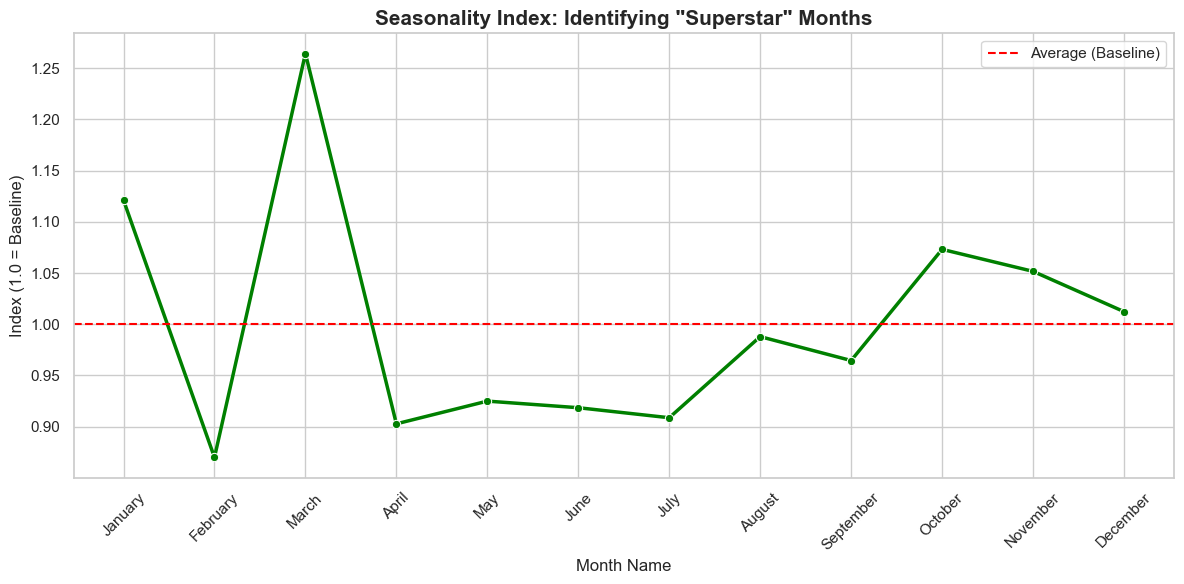

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month Name', y='Seasonality Index', data=seasonal_data, marker='o', color='green', linewidth=2.5)

# Add a baseline at 1.0 (The average)
plt.axhline(1.0, color='red', linestyle='--', label='Average (Baseline)')

plt.title('Seasonality Index: Identifying "Superstar" Months', fontsize=15, fontweight='bold')
plt.ylabel('Index (1.0 = Baseline)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

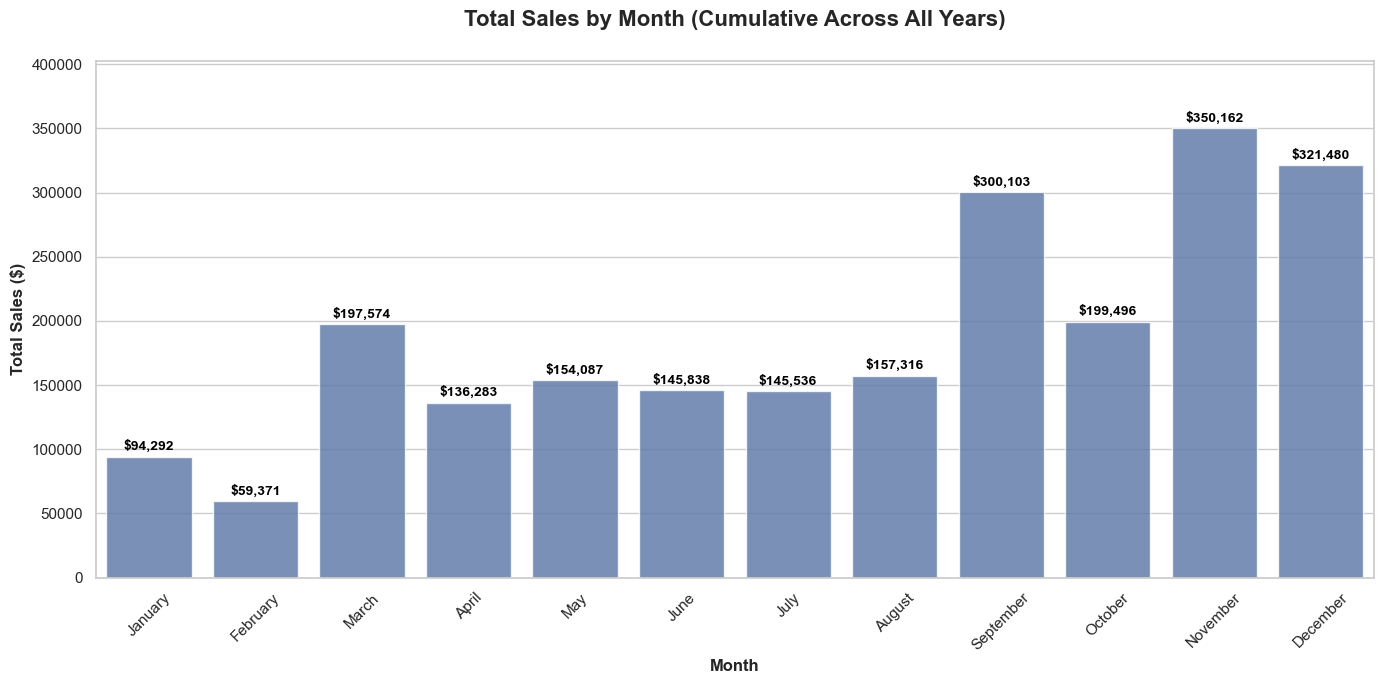

In [ ]:
# Set the visual style (Birinci qrafiklə eyni stil)
sns.set_theme(style="whitegrid")

# Create a figure
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Bar Chart: Total Sales by Month
sns.barplot(
    x='Order Month', 
    y='Sales', 
    data=monthly_summary, 
    ax=ax, 
  
    alpha=0.8,
    legend=False
)

# Set labels and Title (Birinci qrafikdəki formatda)
ax.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_title('Total Sales by Month (Cumulative Across All Years)', fontsize=16, pad=25, fontweight='bold')


ax.set_ylim(0, monthly_summary['Sales'].max() * 1.15)

# 2. Adding data labels on top of bars
for i, v in enumerate(monthly_summary['Sales']):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold', color='black')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Final layout adjustment
plt.tight_layout()
plt.show()

Key insights :  The business demonstrates a clear seasonal pattern with an Average Monthly Sales of $47,115.

Peak Volume: November is the highest-performing month in terms of total revenue, accounting for over $350K in cumulative sales. This suggests a strong end-of-year surge, likely driven by holiday promotions.

Consistency Winner: While November leads in volume, March stands out as the most consistent performer with a Seasonality Index of 1.26, meaning it consistently performs 26% above the monthly average across all years.

Operational Warning: February is identified as the cyclical low point (13% below baseline). Strategic marketing interventions or inventory adjustments are recommended for this period to offset the seasonal dip.

In [ ]:
# Calculate Standard Deviation and Mean for CV
sales_std = monthly_summary['Sales'].std()
sales_mean = monthly_summary['Sales'].mean()

# Formula: CV = Standard Deviation / Mean
cv_value = (sales_std / sales_mean) * 100

print(f"Sales Volatility (CV): {cv_value:.2f}%")

Sales Volatility (CV): 48.15%


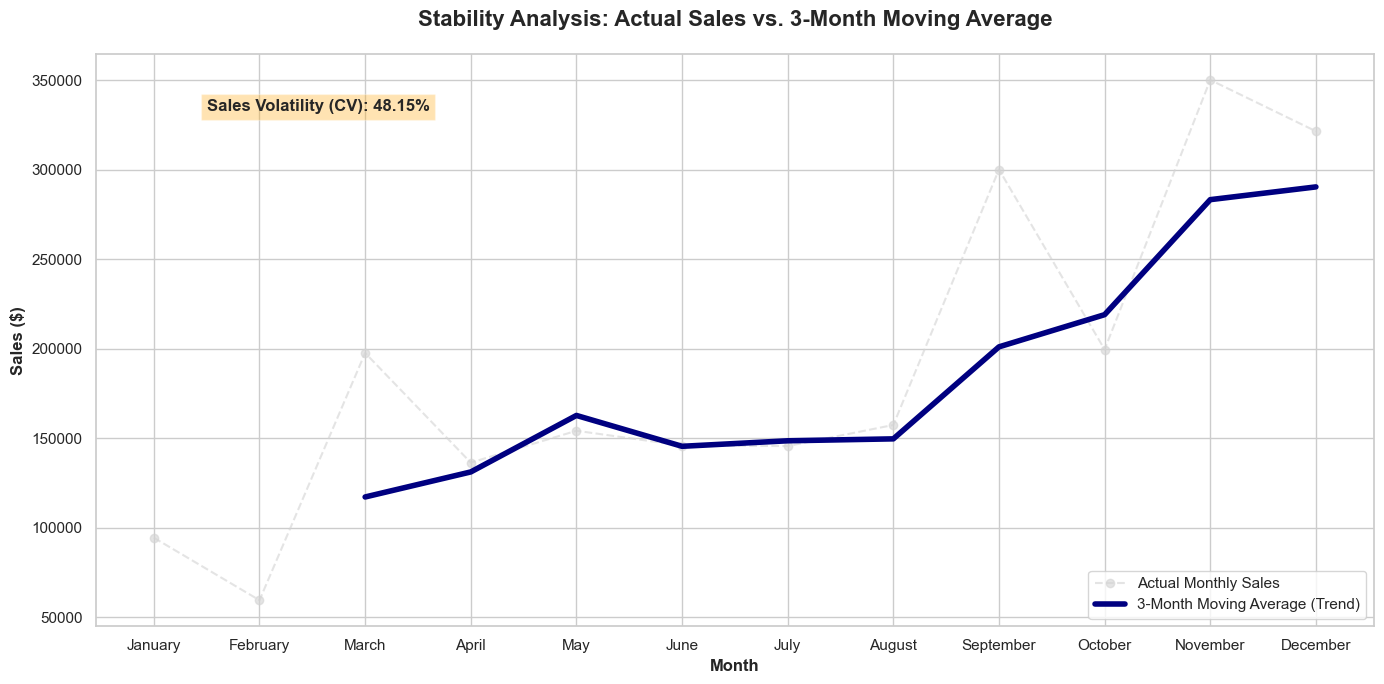

In [ ]:
# 3-Month Moving Average to smooth out short-term fluctuations
monthly_summary['Moving_Avg'] = monthly_summary['Sales'].rolling(window=3).mean()

# Visualization using the same professional style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plotting the Actual Sales
plt.plot(monthly_summary['Order Month'], monthly_summary['Sales'], 
         marker='o', color='lightgray', linestyle='--', label='Actual Monthly Sales', alpha=0.6)

# Plotting the Moving Average (The Real Trend)
plt.plot(monthly_summary['Order Month'], monthly_summary['Moving_Avg'], 
         color='navy', linewidth=4, label='3-Month Moving Average (Trend)')

# Adding the CV value as a KPI box
cv_text = f"Sales Volatility (CV): {cv_value:.2f}%"
plt.text(0.5, monthly_summary['Sales'].max() * 0.95, cv_text, 
         fontsize=12, fontweight='bold', bbox=dict(facecolor='orange', alpha=0.3))

plt.title('Stability Analysis: Actual Sales vs. 3-Month Moving Average', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Key insights: Stability & Growth Trend Analysis

High Volatility (CV: 48.15%):
The business experiences significant monthly sales fluctuations, suggesting potential seasonality and irregular demand patterns, particularly toward the end of the year.

Underlying Growth Trend:
Despite this volatility, the 3-Month Moving Average indicates a clear upward trajectory. This confirms that the business is not solely driven by random spikes, but demonstrates consistent growth momentum, especially from August through December.

Risk Assessment:
The substantial gap between actual sales and the trend line in Q4 highlights a strong reliance on seasonal peaks. To improve revenue stability and forecasting accuracy, the business should consider strengthening sales performance during Q1 and Q2 to reduce dependency on year-end demand.

In [ ]:
# We write the column names exactly as they are in your table.
segment_analysis = df.groupby('Segment').agg({
    'Sales': 'sum'
}).reset_index()

# Let's calculate the sales percentage to make it more interesting.
total_sales_all = segment_analysis['Sales'].sum()
segment_analysis['Share %'] = (segment_analysis['Sales'] / total_sales_all) * 100

# Let's sort the result from largest to smallest.
segment_analysis = segment_analysis.sort_values(by='Sales', ascending=False)

print(segment_analysis)

       Segment         Sales    Share %
0     Consumer  1.148061e+06  50.764619
1    Corporate  6.884941e+05  30.443638
2  Home Office  4.249822e+05  18.791743


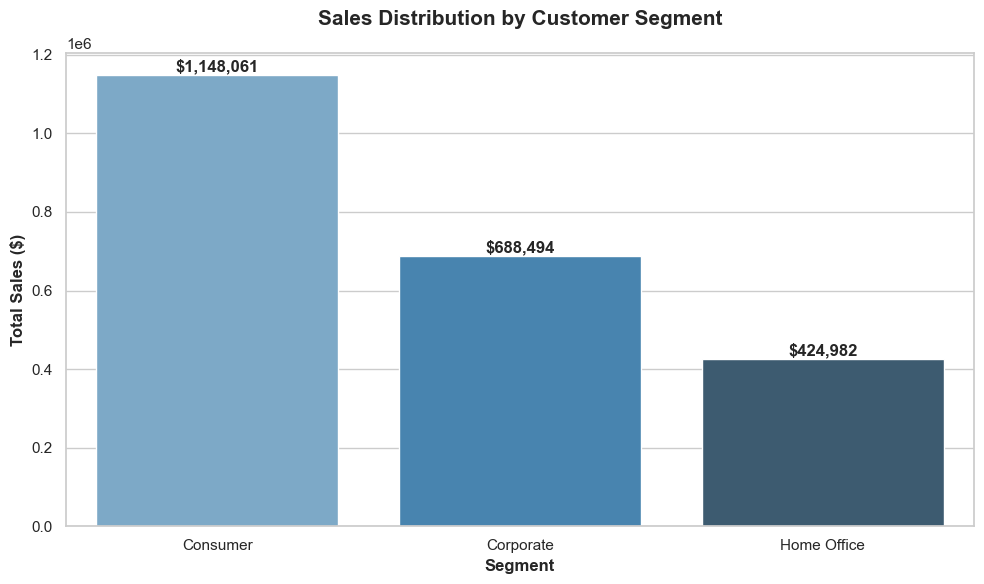

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# We create a bar chart
sns.barplot(
    x='Segment', 
    y='Sales', 
    data=segment_analysis, 
    palette='Blues_d',
    hue='Segment',
    legend=False
)

# Let's write the numbers on the columns.
for i, v in enumerate(segment_analysis['Sales']):
    plt.text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.title('Sales Distribution by Customer Segment', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Total Sales ($)', fontweight='bold')
plt.xlabel('Segment', fontweight='bold')

plt.tight_layout()
plt.show()

Key insights :  Customer Segment Distribution:

Dominant Segment: The Consumer segment is the primary revenue driver, contributing $1,148,061 (approximately 50.8% of total sales). This indicates a strong B2C (Business-to-Consumer) market presence.

Corporate & Home Office: The Corporate segment follows with $688,494, while Home Office contributes the least at $424,982.

Strategic Takeaway: Given that more than half of the revenue comes from fərdi (individual) consumers, marketing strategies and loyalty programs should be heavily tailored toward this group. However, the Corporate segment represents a significant growth opportunity for bulk sales and long-term contracts to stabilize the monthly volatility observed earlier."

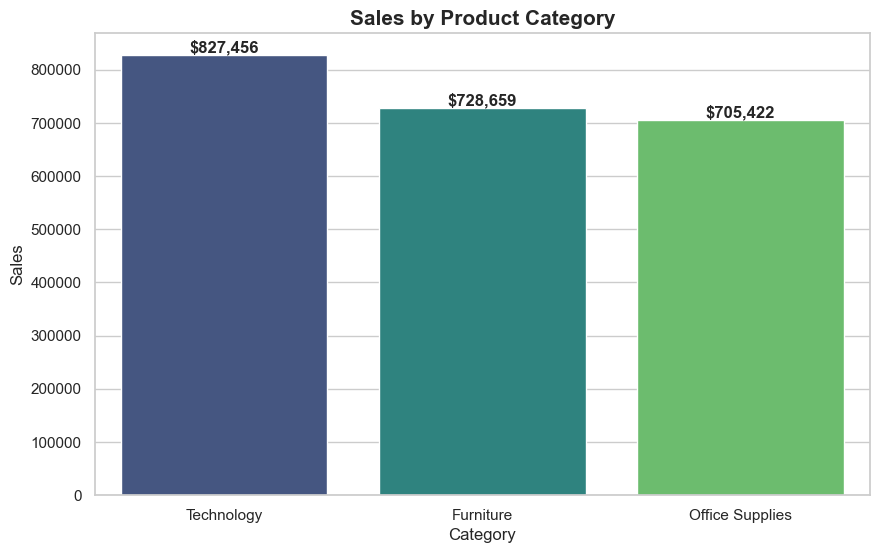

In [ ]:
# Product Category Analysis
category_analysis = df.groupby('Category').agg({'Sales': 'sum'}).reset_index().sort_values(by='Sales', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=category_analysis, palette='viridis', hue='Category', legend=False)

for i, v in enumerate(category_analysis['Sales']):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.title('Sales by Product Category', fontsize=15, fontweight='bold')
plt.show()

Key insights:
Revenue by Product Category:

Leading Category: Technology is the primary revenue driver, generating $827,456. This suggests that high-ticket electronics or specialized tech equipment form the backbone of the company's sales volume.

Balanced Portfolio: There is a narrow margin between Furniture ($728,659) and Office Supplies ($705,422). This balanced distribution indicates that the business does not rely solely on one product type, reducing the risk of a market downturn in any single category.

Strategic Insight: While Technology leads in sales value, Office Supplies typically have higher purchase frequencies. Combining tech sales with recurring office supply subscriptions could be a viable strategy to stabilize the monthly volatility (CV: 48.15%) identified in the previous analysis.

Executive Summary: Sales Performance & Strategic Analysis
Business Overview

This analysis evaluates the company’s growth dynamics, risk exposure, and customer segmentation based on sales data from 2015–2018. The business generated a total revenue of $2.26M, indicating strong overall sales performance.

Key Insights

Growth & Momentum:
The business demonstrates consistent year-over-year growth, with the highest annual increase of 30.64% observed in 2017, indicating strong expansion momentum.

Stability & Risk:
Sales exhibit high volatility (CV: 48.15%), reflecting significant fluctuations in monthly performance. However, the 3-month moving average reveals a clear upward trend, suggesting that despite instability, the underlying business trajectory remains positive.

Seasonality:
Sales patterns indicate clear seasonal behavior. November represents the peak revenue month, while February consistently underperforms. March shows relatively stable performance based on lower variability, indicating more predictable demand during this period.

Customer & Product Mix:
The majority of revenue is generated from the Consumer segment ($1.15M) and the Technology category ($827K). This concentration suggests strong reliance on individual buyers and tech products, while the balanced contribution from Furniture and Office Supplies reflects a moderately diversified product portfolio.

Strategic Recommendations

Risk Mitigation:
To reduce revenue volatility, the business should strengthen performance in Q1 and Q2. Introducing subscription-based models in Office Supplies could help generate recurring revenue and stabilize cash flow.

Customer Strategy:
Marketing efforts should prioritize the high-performing Consumer segment, while expanding long-term contracts with Corporate clients to improve revenue predictability and reduce fluctuations.

Inventory Management:
Inventory planning should align with seasonal demand patterns, ensuring sufficient stock levels ahead of peak months such as November and high-stability periods like March.

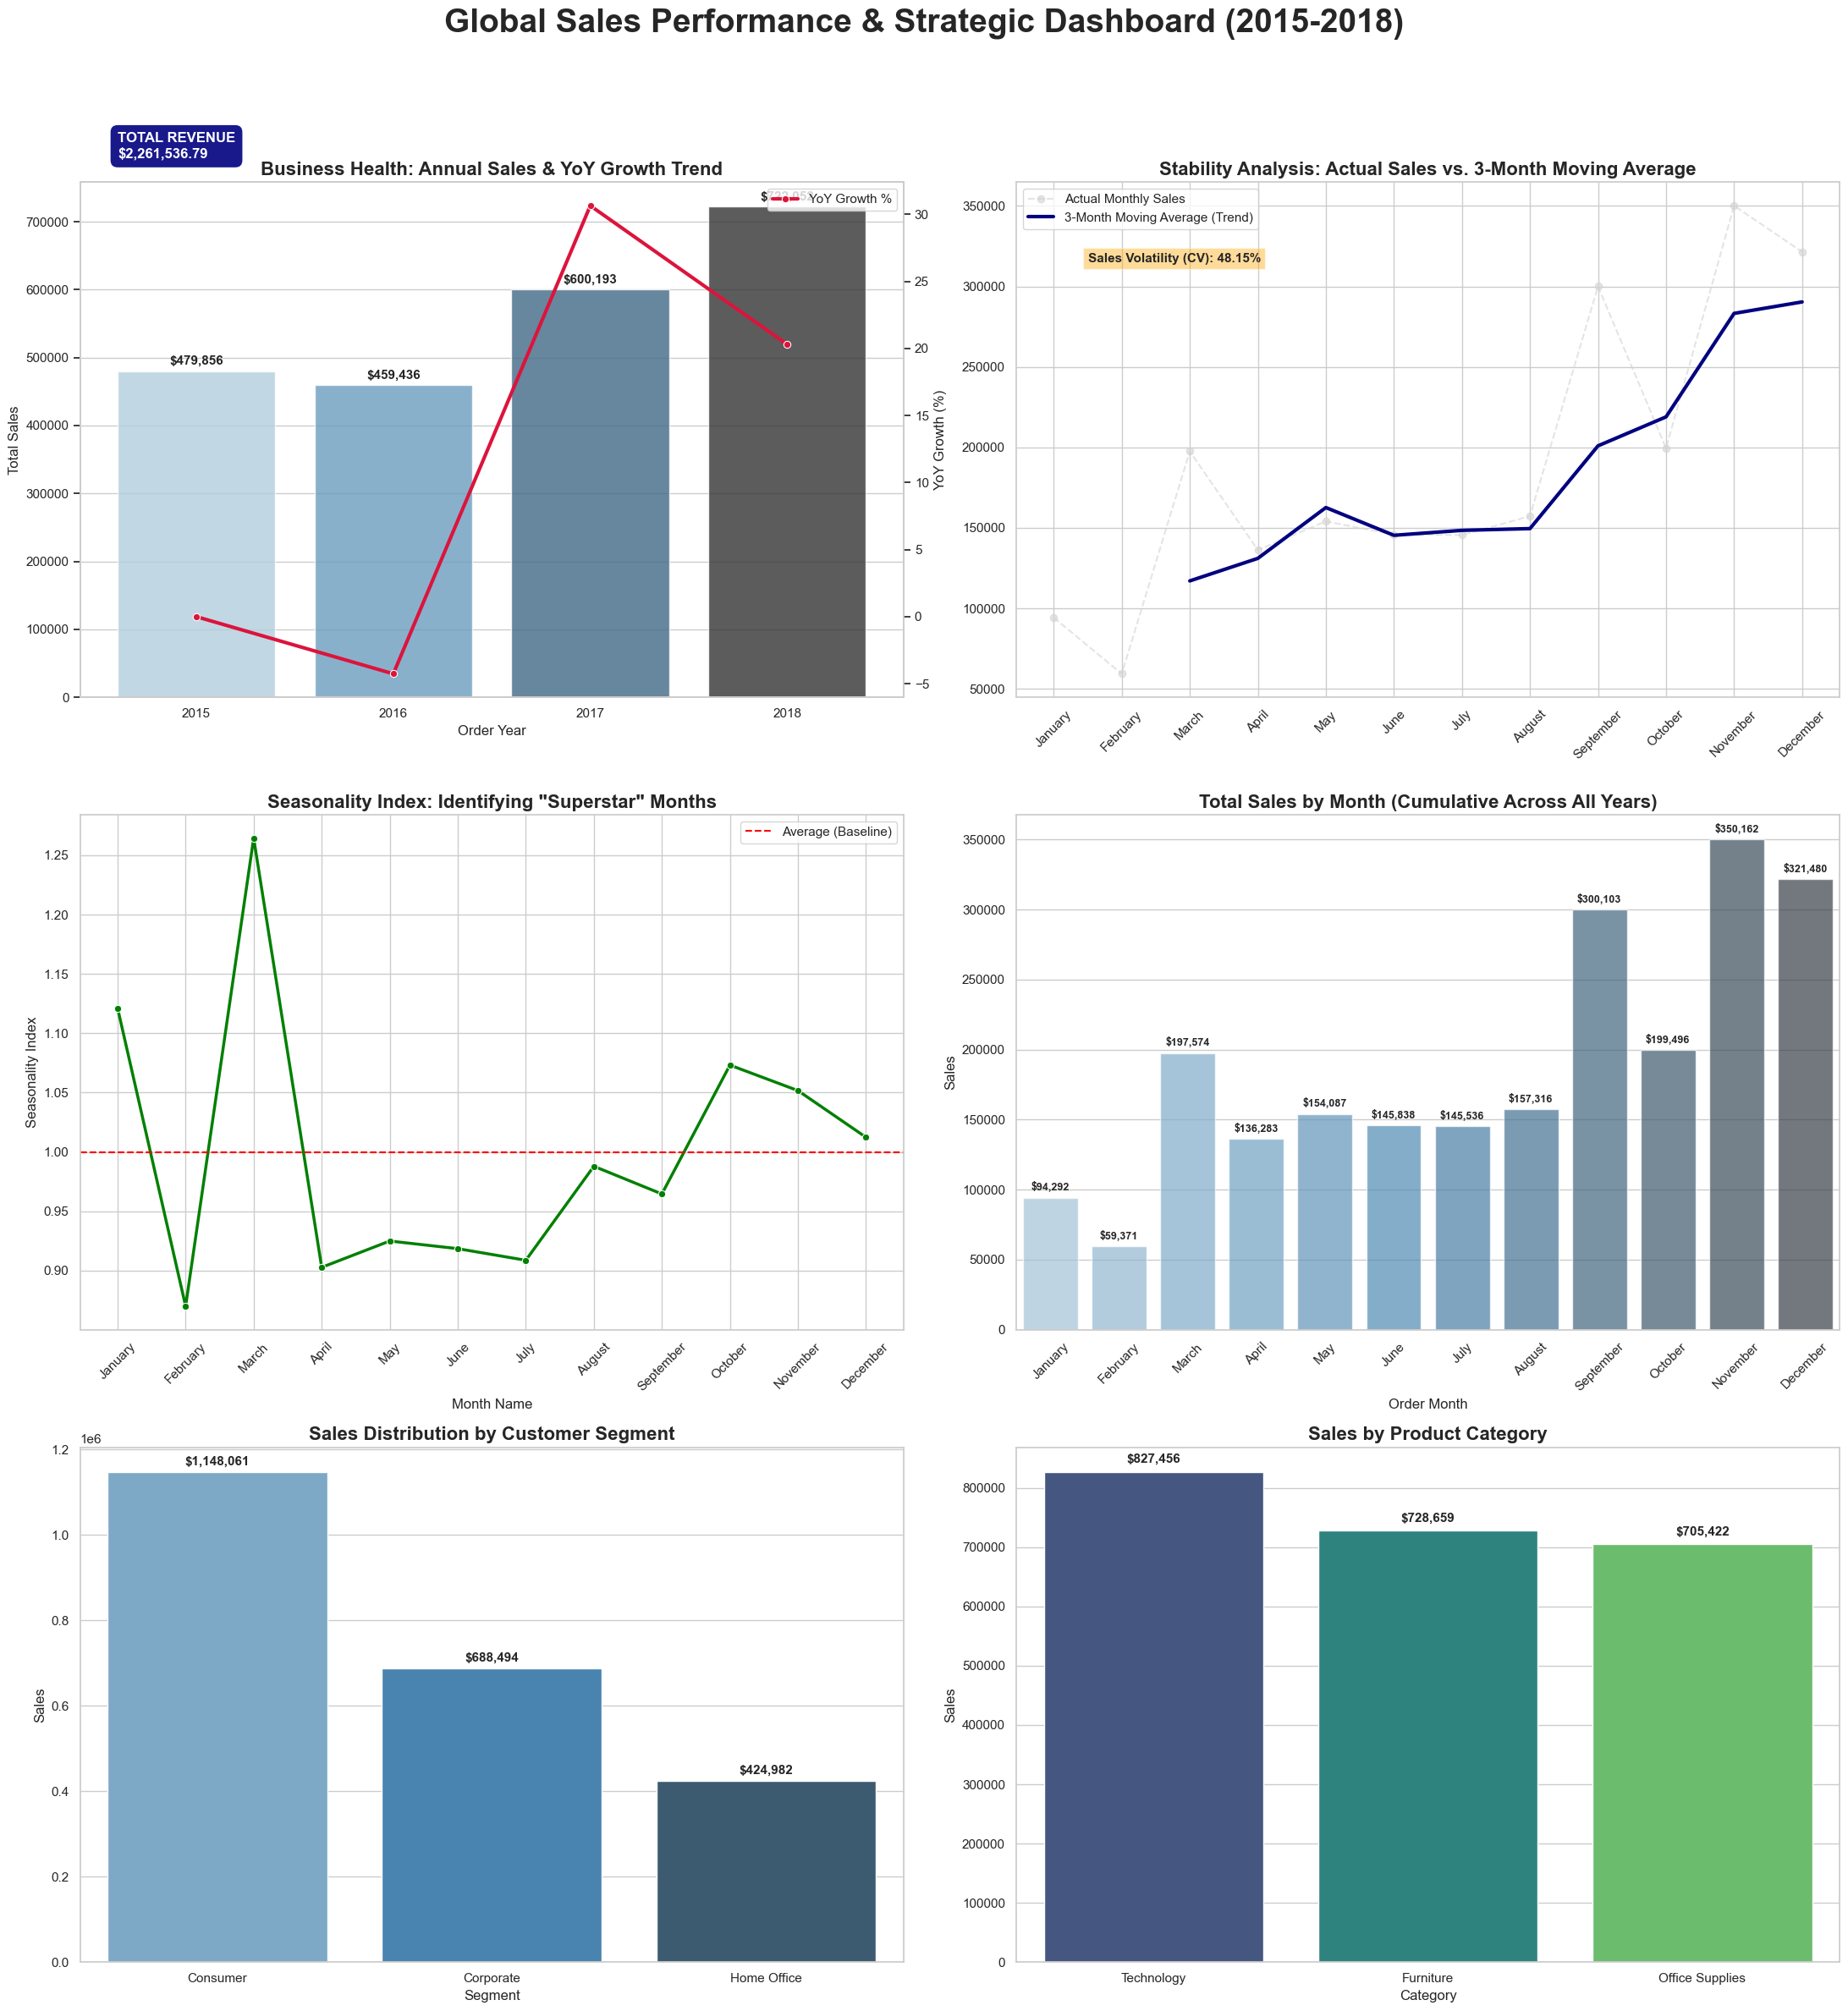

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# We set the overall style of the Dashboard
sns.set_theme(style="whitegrid")

# We create a grid with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(22, 25))
fig.suptitle('Global Sales Performance & Strategic Dashboard (2015-2018)', fontsize=28, fontweight='bold', y=0.98)

# --- 1. TOP LEFT: Business Health (Annual Sales & YoY Growth) ---
ax1 = axes[0, 0]
ax1.set_axisbelow(True)
sns.barplot(x='Order Year', y='Total Sales', data=yearly_summary, ax=ax1, palette='Blues_d', alpha=0.8, hue='Order Year', legend=False)

# We write sales figures on the bars
for i, v in enumerate(yearly_summary['Total Sales']):
    ax1.text(i, v + 10000, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')

# KPI Card: Adding Total Revenue
total_rev = yearly_summary['Total Sales'].sum()
ax1.text(-0.4, yearly_summary['Total Sales'].max() * 1.1, f'TOTAL REVENUE\n${total_rev:,.2f}', 
         fontsize=12, fontweight='bold', color='white', bbox=dict(facecolor='navy', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.5'))

ax1_2 = ax1.twinx()
ax1_2.grid(False)
sns.lineplot(x=range(len(yearly_summary)), y='YoY Growth (%)', data=yearly_summary, marker='o', color='crimson', linewidth=3, ax=ax1_2, label='YoY Growth %')
ax1.set_title('Business Health: Annual Sales & YoY Growth Trend', fontsize=16, fontweight='bold')
ax1_2.legend(loc='upper right')

# --- 2. TOP RIGHT: Stability Analysis (Moving Average) ---
ax2 = axes[0, 1]
ax2.set_axisbelow(True)
ax2.plot(monthly_summary['Order Month'], monthly_summary['Sales'], marker='o', color='lightgray', linestyle='--', label='Actual Monthly Sales', alpha=0.6)
ax2.plot(monthly_summary['Order Month'], monthly_summary['Moving_Avg'], color='navy', linewidth=3, label='3-Month Moving Average (Trend)')
# Sales Volatility KPI box
cv_val = (monthly_summary['Sales'].std() / monthly_summary['Sales'].mean()) * 100
ax2.text(0.5, monthly_summary['Sales'].max()*0.9, f'Sales Volatility (CV): {cv_val:.2f}%', 
         fontsize=11, fontweight='bold', bbox=dict(facecolor='orange', alpha=0.4))
ax2.set_title('Stability Analysis: Actual Sales vs. 3-Month Moving Average', fontsize=16, fontweight='bold')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# --- 3. MIDDLE LEFT: Seasonality Index ---
ax3 = axes[1, 0]
ax3.set_axisbelow(True)
sns.lineplot(x='Month Name', y='Seasonality Index', data=seasonal_data, marker='o', color='green', ax=ax3, linewidth=2.5)
ax3.axhline(1.0, color='red', linestyle='--', label='Average (Baseline)')
ax3.set_title('Seasonality Index: Identifying "Superstar" Months', fontsize=16, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()

# --- 4. MIDDLE RIGHT: Total Sales by Month (Cumulative) ---
ax4 = axes[1, 1]
ax4.set_axisbelow(True)
sns.barplot(x='Order Month', y='Sales', data=monthly_summary, ax=ax4, palette='Blues_d', hue='Order Month', legend=False, alpha=0.7)
for i, v in enumerate(monthly_summary['Sales']):
    ax4.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_title('Total Sales by Month (Cumulative Across All Years)', fontsize=16, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# --- 5. BOTTOM LEFT: Sales Distribution by Segment ---
ax5 = axes[2, 0]
ax5.set_axisbelow(True)
sns.barplot(x='Segment', y='Sales', data=segment_analysis, palette='Blues_d', ax=ax5, hue='Segment', legend=False)
for i, v in enumerate(segment_analysis['Sales']):
    ax5.text(i, v + 15000, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax5.set_title('Sales Distribution by Customer Segment', fontsize=16, fontweight='bold')

# --- 6. BOTTOM RIGHT: Sales by Product Category ---
ax6 = axes[2, 1]
ax6.set_axisbelow(True)
sns.barplot(x='Category', y='Sales', data=category_analysis, palette='viridis', ax=ax6, hue='Category', legend=False)
for i, v in enumerate(category_analysis['Sales']):
    ax6.text(i, v + 15000, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax6.set_title('Sales by Product Category', fontsize=16, fontweight='bold')

# Final adjustment
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()